# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs

Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

0. Neoplastic
1. Inflammatory
2. Connective
3. Dead
4. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

0. Adrenal Gland
1. Bile Duct
2. Bladder
3. Breast
4. Cervix
5. Colon
6. Esophagus
7. Head & Neck
8. Kidney
9. Liver
10. Lung
11. Ovarian
12. Pancreatic
13. Prostate
14. Skin
15. Stomach
16. Testis
17. Thyroid
18. Uterus




In [1]:
%%capture
!pip install datasets

## Libraries

In [2]:
import pandas as pd
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import math
import warnings
import ast
from collections import Counter
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

# 1.Load the Dataset 

In [3]:
%%capture
pannuke_dataset = load_dataset("RationAI/PanNuke")
combined_data = pd.concat([
    pd.DataFrame(pannuke_dataset['fold1']),
    pd.DataFrame(pannuke_dataset['fold2']),
    pd.DataFrame(pannuke_dataset['fold3'])
])

In [4]:
combined_data

,image,instances,categories,tissue
0,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[0, 0, 0, 0, 1, 1, 2, 2]",3
1,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 2]",3
2,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2]",3
3,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",3
4,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[0, 0, 0, 1, 1, 2, 2]",3
...,...,...,...,...
2717,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...",5
2718,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5
2719,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, ...",5
2720,<PIL.PngImagePlugin.PngImageFile image mode=RG...,[<PIL.PngImagePlugin.PngImageFile image mode=1...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",5


# 2.  Visualizations

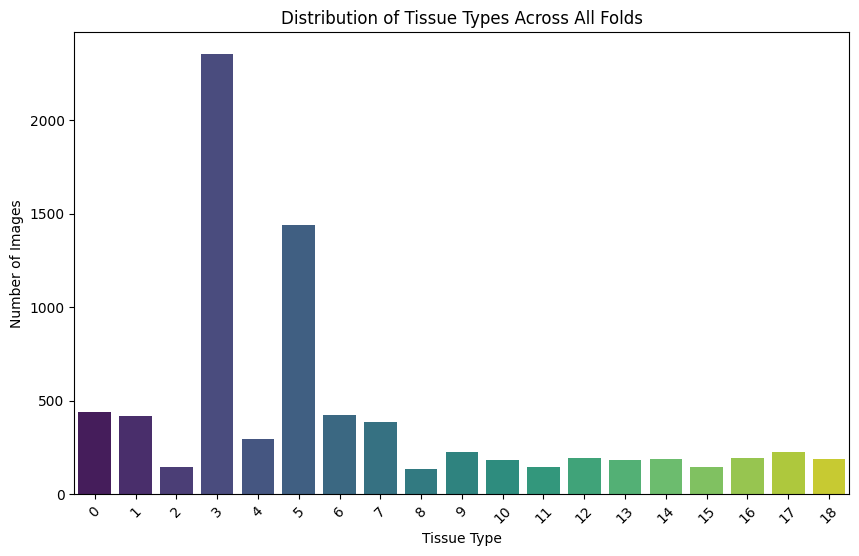

In [5]:
# 📊 1. Bar Plot: Tissue Type Distribution

tissue_distribution = Counter(combined_data['tissue'].explode())  # Count tissue types

plt.figure(figsize=(10, 6))
sns.barplot(x=list(tissue_distribution.keys()), y=list(tissue_distribution.values()), palette='viridis')
plt.xticks(rotation=45)
plt.title("Distribution of Tissue Types Across All Folds")
plt.xlabel("Tissue Type")
plt.ylabel("Number of Images")
plt.show()

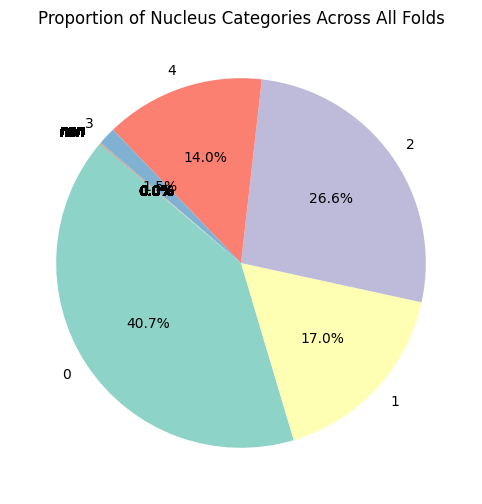

In [6]:
# 🧠 2. Pie Chart: Nucleus Category Distribution

nucleus_category_distribution = Counter(combined_data['categories'].explode()) # Count nucleus categories

plt.figure(figsize=(8, 6))
plt.pie(nucleus_category_distribution.values(), labels=nucleus_category_distribution.keys(), 
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
plt.title("Proportion of Nucleus Categories Across All Folds")
plt.show()


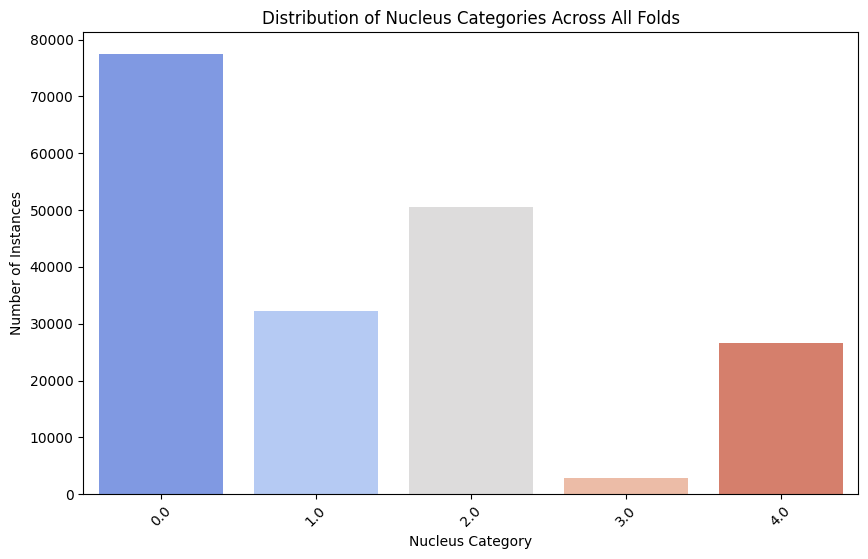

In [7]:
# Bar Plot: Nucleus Category Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=list(nucleus_category_distribution.keys()), y=list(nucleus_category_distribution.values()), palette='coolwarm')

plt.xticks(rotation=45)
plt.title("Distribution of Nucleus Categories Across All Folds")
plt.xlabel("Nucleus Category")
plt.ylabel("Number of Instances")
plt.show()


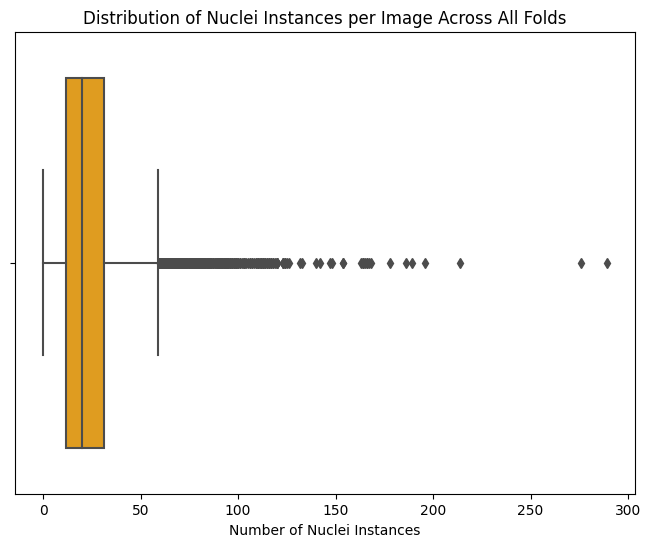

In [8]:
# 📈 3. Box Plot: Nuclei Instances per Image

nuclei_instance_counts = combined_data['instances'].apply(len)  # Count instances in each image

plt.figure(figsize=(8, 6))
sns.boxplot(x=nuclei_instance_counts, color='orange')
plt.title("Distribution of Nuclei Instances per Image Across All Folds")
plt.xlabel("Number of Nuclei Instances")
plt.show()


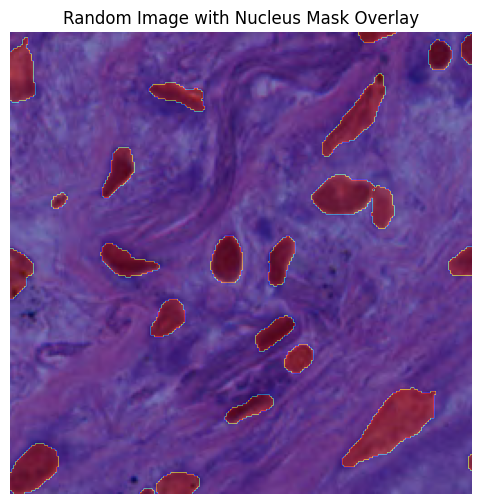

In [9]:
# 🟠 4. Heatmap: Example Mask Overlay on Image

# Select a random image with instances
random_index = random.randint(0, len(combined_data) - 1)
random_image = np.array(combined_data['image'].iloc[random_index])
random_mask_stack = np.sum(np.array(combined_data['instances'].iloc[random_index]), axis=0)

plt.figure(figsize=(10, 6))
plt.imshow(random_image)
plt.imshow(random_mask_stack, cmap='jet', alpha=0.5)  # Heatmap overlay
plt.title("Random Image with Nucleus Mask Overlay")
plt.axis("off")
plt.show()


# 3. Sample Display

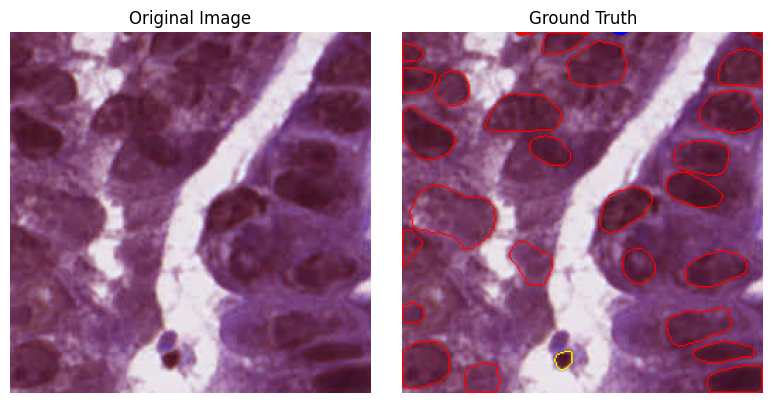

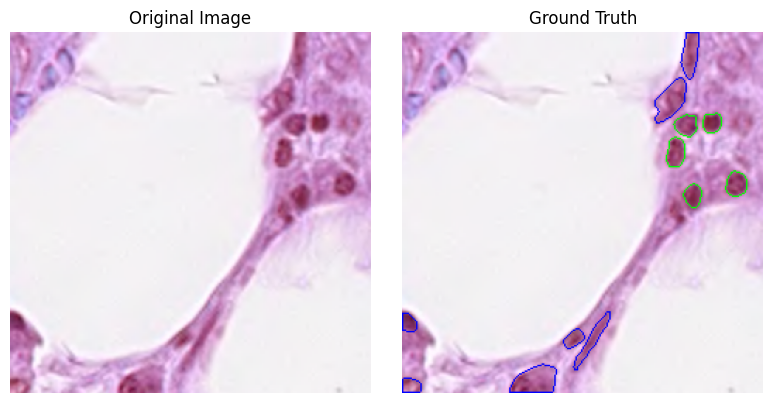

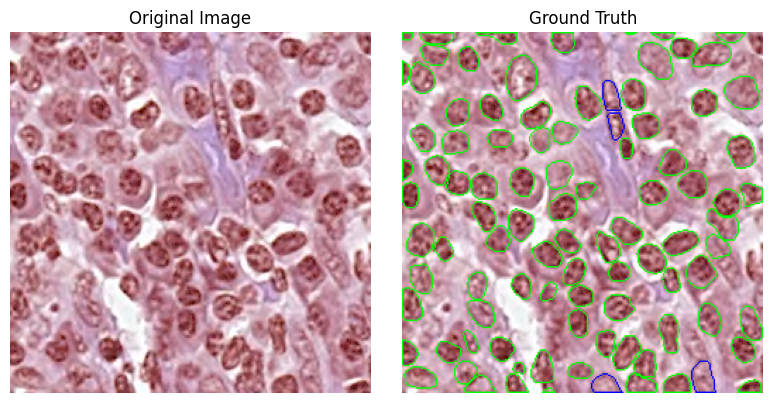

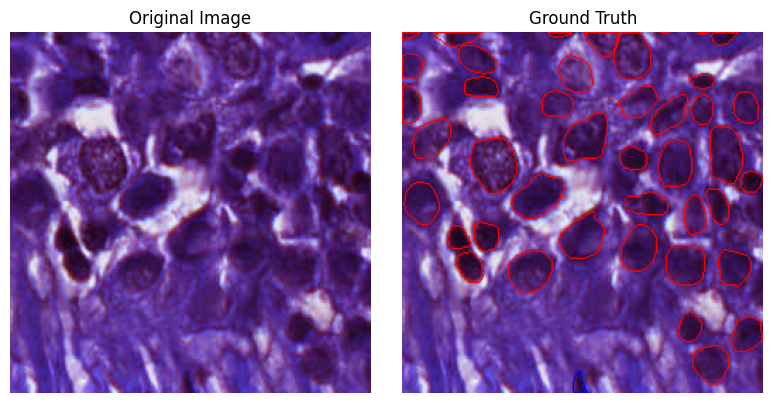

In [10]:
def visualize_random_samples(dataset, num_samples=3):
    random_samples = dataset.sample(num_samples).reset_index(drop=True)
    category_colors = {
    "0": (255, 0, 0),    # Neoplastic - Red
    "1": (0, 255, 0),    # Inflammatory - Green
    "2": (0, 0, 255),    # Connective - Blue
    "3": (255, 255, 0),  # Dead - Yellow
    "4": (255, 0, 255)   # Epithelial - Magenta
    } 
    
    for idx, row in random_samples.iterrows():
        image = row['image']
        instances = row['instances']
        categories = row['categories']
        
        # Convert PIL image to NumPy array for visualization
        image = np.array(image)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        overlay = image.copy()
        
        # Draw contours for each mask
        for mask, category in zip(instances, categories):
            mask = np.array(mask)

            # Ensure mask is uint8 for OpenCV compatibility
            mask = mask.astype(np.uint8) * 255
            
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            color = category_colors.get(str(category), (255, 255, 255))
            cv2.drawContours(overlay, contours, -1, color, thickness=1)

        # Plot the original and annotated images
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(image)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        axes[1].imshow(overlay)
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

# Visualize 3 random samples
visualize_random_samples(combined_data, num_samples=4)
